<a href="https://colab.research.google.com/github/janani-pb/amazonprime_content_analysis/blob/main/AmazonPrime_content__analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn sqlite3

ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)
ERROR: No matching distribution found for sqlite3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set(style="whitegrid")

In [3]:
prime_df = pd.read_csv("amazon_prime_titles.csv")
imdb_df = pd.read_csv("imdb_dataset.csv")

In [4]:
print(prime_df.head())
print(prime_df.info())


  show_id   type                 title        director  \
0      s1  Movie   The Grand Seduction    Don McKellar   
1      s2  Movie  Take Care Good Night    Girish Joshi   
2      s3  Movie  Secrets of Deception     Josh Webber   
3      s4  Movie    Pink: Staying True  Sonia Anderson   
4      s5  Movie         Monster Maker    Giles Foster   

                                                cast         country  \
0     Brendan Gleeson, Taylor Kitsch, Gordon Pinsent          Canada   
1   Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar           India   
2  Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...   United States   
3  Interviews with: Pink, Adele, Beyoncé, Britney...   United States   
4  Harry Dean Stanton, Kieran O'Brien, George Cos...  United Kingdom   

       date_added  release_year rating duration                listed_in  \
0  March 30, 2021          2014    NaN  113 min            Comedy, Drama   
1  March 30, 2021          2018    13+  110 min     Drama, Interna

In [5]:
print(imdb_df.head())
print(imdb_df.info())

                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

                         

In [6]:
print(prime_df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [7]:
prime_df.rename(columns={'listed_in': 'genre'}, inplace=True)

In [8]:
prime_df = prime_df.dropna(subset=['genre', 'country'])



In [9]:
imdb_df = imdb_df.dropna(subset=['Genre', 'IMDB_Rating'])

In [10]:
imdb_df.rename(columns={
    'Series_Title': 'title',
    'Genre': 'genre',
    'IMDB_Rating': 'rating'
}, inplace=True)

In [11]:
prime_df['title'] = prime_df['title'].str.lower()

In [12]:
imdb_df['title'] = imdb_df['title'].str.lower()

In [13]:
merged_df = pd.merge(prime_df, imdb_df, on='title', how='inner')
print(merged_df.head(5))

  show_id   type                  title                       director  \
0   s1228  Movie                  raazi                  Meghna Gulzar   
1   s2249  Movie       harold and maude                      Hal Ashby   
2   s3947  Movie                tumbbad  Rahi Anil Barve, Adesh Prasad   
3   s4321  Movie  it's a wonderful life                    Frank Capra   
4   s4693  Movie  manchester by the sea               Kenneth Lonergan   

                                                cast        country  \
0                          Alia Bhatt, Vicky Kaushal          India   
1                Ruth Gordon, Bud Cort, Tom Skerritt  United States   
2  Sohum Shah, Jyoti Malshe, Dhundhiraj Prabhakar...  India, Sweden   
3  James Stewart, Donna Reed, Lionel Barrymore, T...  United States   
4  Casey Affleck, Michelle Williams, Kyle Chandle...  United States   

  date_added  release_year rating_x duration  ... rating_y  \
0        NaN          2018      13+  137 min  ...      7.8   
1   

In [14]:
print(merged_df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating_x', 'duration', 'genre_x', 'description',
       'Poster_Link', 'Released_Year', 'Certificate', 'Runtime', 'genre_y',
       'rating_y', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2',
       'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')


In [15]:
merged_df['genre'] = merged_df['genre_x']

In [16]:
merged_df['genre'] = merged_df['genre_x'].fillna(merged_df['genre_y'])

In [17]:
print(prime_df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')


In [18]:
print(imdb_df.columns)

Index(['Poster_Link', 'title', 'Released_Year', 'Certificate', 'Runtime',
       'genre', 'rating', 'Overview', 'Meta_score', 'Director', 'Star1',
       'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')


In [19]:
merged_df['genre'] = merged_df['genre'].str.split(',')
merged_df = merged_df.explode('genre')
merged_df['genre'] = merged_df['genre'].str.strip()

In [20]:
genre_counts = merged_df['genre'].value_counts()

print(genre_counts.head(10))

genre
Drama              10
Suspense            5
Comedy              5
International       4
Horror              1
Fantasy             1
Romance             1
Action              1
Science Fiction     1
Name: count, dtype: int64


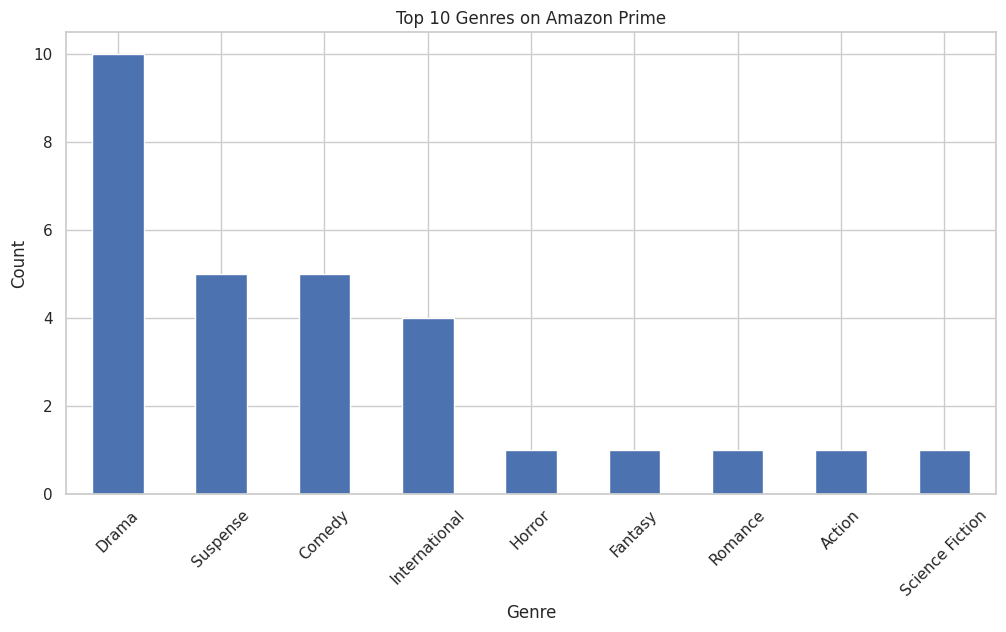

In [21]:
plt.figure(figsize=(12,6))
genre_counts.head(10).plot(kind='bar')
plt.title("Top 10 Genres on Amazon Prime")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [22]:
country_counts = merged_df['country'].value_counts()

print(country_counts.head(10))

country
United States                    12
India                            10
India, Sweden                     3
United States, Sweden, Norway     3
United States, Canada             1
Name: count, dtype: int64


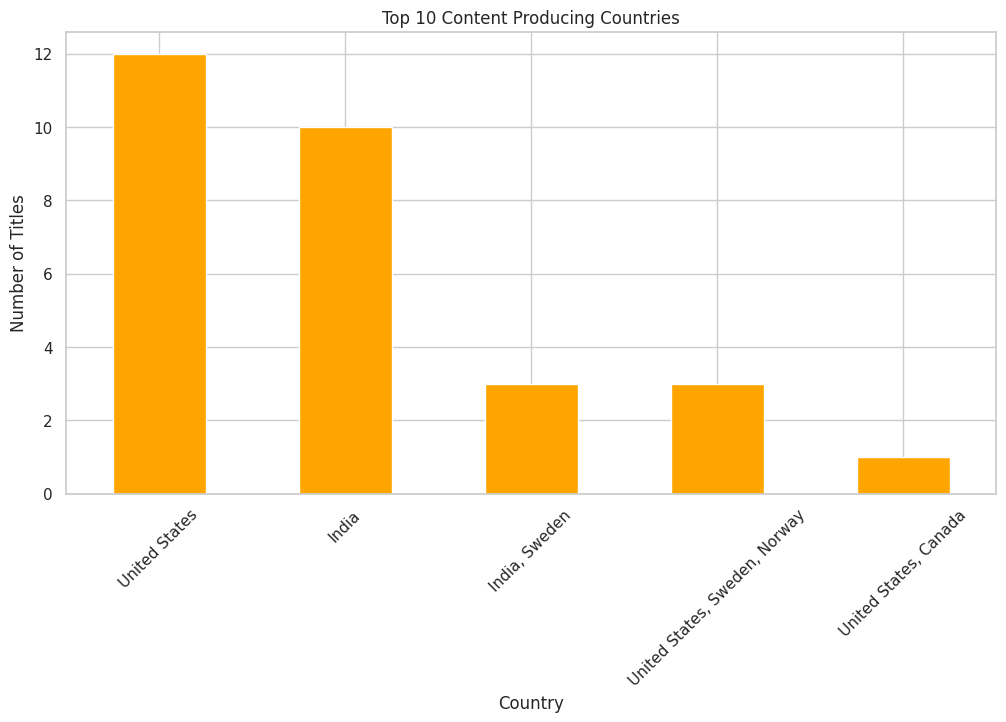

In [23]:
plt.figure(figsize=(12,6))
country_counts.head(10).plot(kind='bar', color='orange')
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

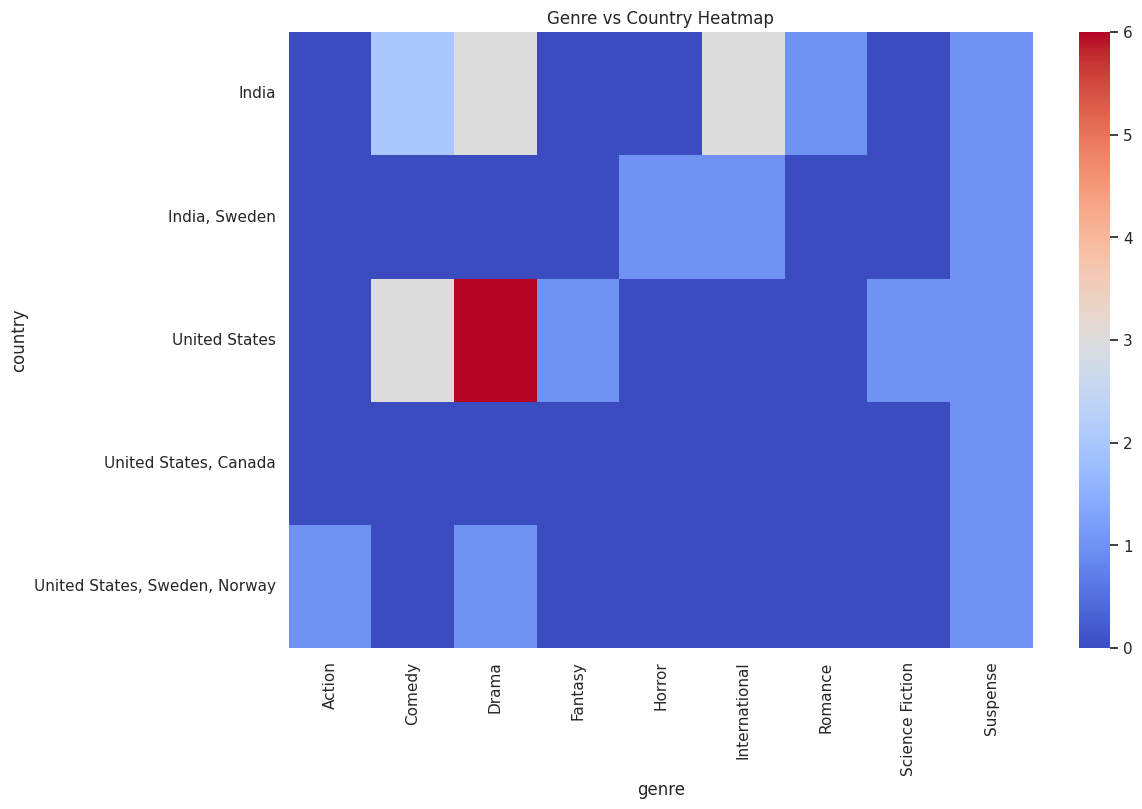

In [24]:
pivot_table = pd.pivot_table(
    merged_df,
    values='title',
    index='country',
    columns='genre',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table.head(10), cmap='coolwarm')
plt.title("Genre vs Country Heatmap")
plt.show()

In [25]:
print(merged_df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating_x', 'duration', 'genre_x', 'description',
       'Poster_Link', 'Released_Year', 'Certificate', 'Runtime', 'genre_y',
       'rating_y', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2',
       'Star3', 'Star4', 'No_of_Votes', 'Gross', 'genre'],
      dtype='object')


In [26]:
merged_df.rename(columns={'IMDB_Rating': 'rating'}, inplace=True)

In [27]:
merged_df['rating'] = merged_df['rating_x'].fillna(merged_df['rating_y'])

In [28]:
top_genres = merged_df.groupby('genre')['rating_y'].mean().sort_values(ascending=False)

print(top_genres.head(10))

genre
Fantasy            8.60
Horror             8.30
International      8.15
Romance            8.10
Suspense           8.04
Comedy             8.02
Drama              7.96
Action             7.80
Science Fiction    7.60
Name: rating_y, dtype: float64


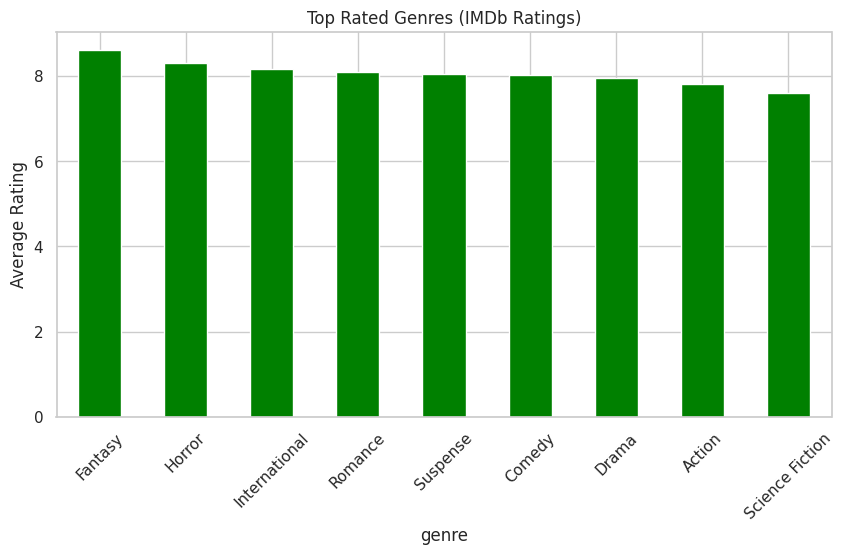

In [29]:
plt.figure(figsize=(10,5))
top_genres.head(10).plot(kind='bar', color='green')
plt.title("Top Rated Genres (IMDb Ratings)")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

In [30]:
merged_df.rename(columns={
    'director': 'prime_director',
    'Director': 'imdb_director'
}, inplace=True)

In [31]:
conn = sqlite3.connect("streaming_analysis.db")
merged_df.to_sql("prime_imdb", conn, if_exists='replace', index=False)

29

In [32]:
# Rename important columns
merged_df.rename(columns={
    'Director': 'imdb_director',
    'rating_y': 'rating'
}, inplace=True)

# Remove unnecessary duplicates
merged_df.drop(columns=['genre_x', 'genre_y', 'rating_x'], inplace=True, errors='ignore')

In [33]:
print(merged_df.columns)

Index(['show_id', 'type', 'title', 'prime_director', 'cast', 'country',
       'date_added', 'release_year', 'duration', 'description', 'Poster_Link',
       'Released_Year', 'Certificate', 'Runtime', 'rating', 'Overview',
       'Meta_score', 'imdb_director', 'Star1', 'Star2', 'Star3', 'Star4',
       'No_of_Votes', 'Gross', 'genre', 'rating'],
      dtype='object')


In [34]:
merged_df = merged_df.loc[:, ~merged_df.columns.duplicated()]

In [35]:
print(merged_df.columns)

Index(['show_id', 'type', 'title', 'prime_director', 'cast', 'country',
       'date_added', 'release_year', 'duration', 'description', 'Poster_Link',
       'Released_Year', 'Certificate', 'Runtime', 'rating', 'Overview',
       'Meta_score', 'imdb_director', 'Star1', 'Star2', 'Star3', 'Star4',
       'No_of_Votes', 'Gross', 'genre'],
      dtype='object')


In [36]:
import sqlite3

conn = sqlite3.connect("streaming_analysis.db")
merged_df.to_sql("prime_imdb", conn, if_exists='replace', index=False)

29

In [37]:
conn = sqlite3.connect("streaming_analysis.db")
merged_df.to_sql("prime_imdb", conn, if_exists='replace', index=False)

29

In [38]:
query1 = """
SELECT genre, COUNT(*) as count
FROM prime_imdb
GROUP BY genre
ORDER BY count DESC
LIMIT 10;
"""
print(pd.read_sql(query1, conn))

             genre  count
0            Drama     10
1         Suspense      5
2           Comedy      5
3    International      4
4  Science Fiction      1
5          Romance      1
6           Horror      1
7          Fantasy      1
8           Action      1


In [39]:
query2 = """
SELECT country, COUNT(*) as total
FROM prime_imdb
GROUP BY country
ORDER BY total DESC
LIMIT 10;
"""
print(pd.read_sql(query2, conn))

                         country  total
0                  United States     12
1                          India     10
2  United States, Sweden, Norway      3
3                  India, Sweden      3
4          United States, Canada      1


In [40]:
query3 = """
SELECT genre, AVG(rating) as avg_rating
FROM prime_imdb
GROUP BY genre
ORDER BY avg_rating DESC
LIMIT 10;
"""
print(pd.read_sql(query3, conn))

             genre  avg_rating
0          Fantasy        8.60
1           Horror        8.30
2    International        8.15
3          Romance        8.10
4         Suspense        8.04
5           Comedy        8.02
6            Drama        7.96
7           Action        7.80
8  Science Fiction        7.60
